## **Healthcare Analytics: Stroke Risk Prediction Using Business Intelligence Decisions**

# **Main Objective**:

The main objective of this project is to perform a comprehensive data analytics and exploratory visualization pipeline on the Clinical Stroke Risk Prediction Dataset using Python. By leveraging data profiling and statistical metrics, the project aims to identify key health indicators (KPIs), discover critical medical risk thresholds, and visualize patient lifestyle trends to provide actionable clinical intelligence for healthcare management.

* **Extract Baseline Healthcare KPIs**: Calculate dataset-wide operational metrics including Total Patient Population, Overall Stroke Prevalence Rate (%), Average Glucose Levels, and Average BMI across varied demographics.
* **Identify Clinical Risk Thresholds:** Analyze the absolute numerical distributions of avg_glucose_level and bmi to locate the exact statistical tipping points where stroke frequencies accelerate.
* **Evaluate Co-morbidity Correlation Workloads:** Measure the compounding impact of pre-existing conditions like hypertension and heart disease to quantify how significantly they elevate stroke occurrence rates.
* **Segment Behavioral & Lifestyle Risk Patterns:** Audit and compare stroke distribution patterns against daily lifestyle indicators including smoking_status, work_type, and ever_married attributes.
* **Map Demographic Patient Vulnerabilities:** Investigate how physiological traits like age groups and structural factors like Residence_type (Rural vs Urban) intersect with active medical risks.
* **Create Interactive Dashboard Reports:** Deploy dynamic, filterable exploratory visualizations using Plotly Express and Seaborn to allow seamless medical data profiling and diagnostic reporting.

# **Dataset information**

**Source : Mendeley Data**

**Location : Anonymized Clinical Records (Specific hospital names and geographic regions are fully removed to protect patient privacy)**

**Year/Timeline : Data collected during the period 2026**

**Domain: Public Health,Healthcare Research**

**Dataset Size : 22,420 rows  and 13 cloumns**

In [2]:
# import Libraries:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import gradio as gr

In [3]:
# Import CSV using Pandas
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [4]:
file_path = '/content/drive/MyDrive/Final project dataset/Clinical Stroke Risk Prediction Dataset.csv'
df = pd.read_csv(file_path)
df


,S.no,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,0,90001,Female,77.0,1,0,Yes,Self-employed,Rural,176.71,33.2,never smoked,0
1,1,90002,Male,18.0,0,0,No,Private,Urban,80.07,22.3,Unknown,0
2,2,90003,Male,11.0,0,0,No,children,Rural,56.33,18.1,Unknown,0
3,3,90004,Female,16.0,0,0,No,Private,Urban,87.16,28.2,never smoked,0
4,4,90005,Female,73.0,0,1,Yes,Private,Rural,102.46,29.7,never smoked,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
22415,22415,112416,Female,80.0,1,0,Yes,Private,Urban,83.75,NaN,never smoked,0
22416,22416,112417,Female,81.0,0,0,Yes,Self-employed,Urban,125.20,40.0,never smoked,0
22417,22417,112418,Female,35.0,0,0,Yes,Self-employed,Rural,82.99,30.6,never smoked,0
22418,22418,112419,Male,51.0,0,0,Yes,Private,Rural,166.29,25.6,formerly smoked,0


In [5]:
# finding rows
df.shape

(22420, 13)

**ATTRIBUTES DETAILS**
| Column Name | Feature Nature  | Feature Description |
| :--- | :--- | :--- |
| **`id`** | Unique Identifier | Unique tracking number for each patient record. |
| **`gender`** | Demographic Attribute | Patient gender (Male, Female, or Other). |
| **`age`** | Demographic Attribute | Age of the patient in years. |
| **`hypertension`** | Raw Clinical Indicator | High blood pressure history (0 = No, 1 = Yes). |
| **`heart_disease`** | Raw Clinical Indicator | Pre-existing heart conditions (0 = No, 1 = Yes). |
| **`ever_married`** | Lifestyle Attribute | Marital status history of the patient (Yes or No). |
| **`work_type`** | Lifestyle Attribute | Employment category (Private, Govt_job, Self-employed, etc). |
| **`Residence_type`** | Environmental Attribute | Living environment category (Urban or Rural). |
| **`avg_glucose_level`**| Continuous Clinical Metric | Average blood glucose level of the patient (mg/dL). |
| **`bmi`** | Continuous Clinical Metric | Body Mass Index of the patient (kg/m2). |
| **`smoking_status`** | Behavioral Attribute | Smoking history (never smoked, smokes, formerly smoked, Unknown). |
| **`stroke`** | Target Variable / Output KPI | Indicates if the patient suffered a stroke (0 = No, 1 = Yes). |

In [6]:
# Previewing Top 5 Records
print(df.head())

   S.no     id  gender   age  hypertension  heart_disease ever_married  \
0     0  90001  Female  77.0             1              0          Yes   
1     1  90002    Male  18.0             0              0           No   
2     2  90003    Male  11.0             0              0           No   
3     3  90004  Female  16.0             0              0           No   
4     4  90005  Female  73.0             0              1          Yes   

       work_type Residence_type  avg_glucose_level   bmi smoking_status  \
0  Self-employed          Rural             176.71  33.2   never smoked   
1        Private          Urban              80.07  22.3        Unknown   
2       children          Rural              56.33  18.1        Unknown   
3        Private          Urban              87.16  28.2   never smoked   
4        Private          Rural             102.46  29.7   never smoked   

   stroke  
0       0  
1       0  
2       0  
3       0  
4       0  


In [7]:
# Checking Data Types and Structural Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22420 entries, 0 to 22419
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   S.no               22420 non-null  int64  
 1   id                 22420 non-null  int64  
 2   gender             22420 non-null  object 
 3   age                22420 non-null  float64
 4   hypertension       22420 non-null  int64  
 5   heart_disease      22420 non-null  int64  
 6   ever_married       22420 non-null  object 
 7   work_type          22420 non-null  object 
 8   Residence_type     22420 non-null  object 
 9   avg_glucose_level  22420 non-null  float64
 10  bmi                21561 non-null  float64
 11  smoking_status     22420 non-null  object 
 12  stroke             22420 non-null  int64  
dtypes: float64(3), int64(5), object(5)
memory usage: 2.2+ MB


In [8]:
# Generating Statistical Summary for Numerical Metrics
print(df.describe())

               S.no             id           age  hypertension  heart_disease  \
count  22420.000000   22420.000000  22420.000000  22420.000000   22420.000000   
mean   11209.500000  101210.500000     43.073229      0.096387       0.052676   
std     6472.240854    6472.240854     22.600148      0.295128       0.223391   
min        0.000000   90001.000000      0.080000      0.000000       0.000000   
25%     5604.750000   95605.750000     25.000000      0.000000       0.000000   
50%    11209.500000  101210.500000     45.000000      0.000000       0.000000   
75%    16814.250000  106815.250000     61.000000      0.000000       0.000000   
max    22419.000000  112420.000000     82.000000      1.000000       1.000000   

       avg_glucose_level           bmi        stroke  
count       22420.000000  21561.000000  22420.000000  
mean          105.927644     28.861556      0.044425  
std            45.124252      7.845364      0.206041  
min            55.120000     10.300000      0.0000

In [9]:
# Null Value Verification Check
print(df.isnull().sum())

S.no                   0
id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  859
smoking_status         0
stroke                 0
dtype: int64


In [10]:
# Duplicate Records Check
print(f"Total Duplicate Rows Found: {df.duplicated().sum()}")

Total Duplicate Rows Found: 0


In [11]:
# Standardize categories
categorical_cols = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']
for col in categorical_cols:
    print(f"Unique values in '{col}': {df[col].unique()}")


Unique values in 'gender': ['Female' 'Male' 'Other']
Unique values in 'ever_married': ['Yes' 'No']
Unique values in 'work_type': ['Self-employed' 'Private' 'children' 'Govt_job' 'Never_worked']
Unique values in 'Residence_type': ['Rural' 'Urban']
Unique values in 'smoking_status': ['never smoked' 'Unknown' 'smokes' 'formerly smoked']


# **DATA CLEAING AND TRANSFORMATION**

In [12]:
# fresh file read from the old
df_old = pd.read_csv(file_path)
df_new = df_old.copy()

In [13]:
# delete unwanted columns
# drop s.no column
df_new = df_new.drop(columns=['S.no'])
print(df_new)

           id  gender   age  hypertension  heart_disease ever_married  \
0       90001  Female  77.0             1              0          Yes   
1       90002    Male  18.0             0              0           No   
2       90003    Male  11.0             0              0           No   
3       90004  Female  16.0             0              0           No   
4       90005  Female  73.0             0              1          Yes   
...       ...     ...   ...           ...            ...          ...   
22415  112416  Female  80.0             1              0          Yes   
22416  112417  Female  81.0             0              0          Yes   
22417  112418  Female  35.0             0              0          Yes   
22418  112419    Male  51.0             0              0          Yes   
22419  112420  Female  44.0             0              0          Yes   

           work_type Residence_type  avg_glucose_level   bmi   smoking_status  \
0      Self-employed          Rural       

In [14]:
# age convert into whole number
df_new['age'] = np.ceil(df_new['age']).astype(int)


In [15]:
# check age convert into whole number using id
target_id = 90730
age = df_new[df_new['id'] == target_id]['age'].values[0]

print(f"ID {target_id} age is : {age}")

ID 90730 age is : 1


In [16]:
# In work columns change all first letter in capital
df_new['work_type'] = df_new['work_type'].str.title()
print(df_new)

           id  gender  age  hypertension  heart_disease ever_married  \
0       90001  Female   77             1              0          Yes   
1       90002    Male   18             0              0           No   
2       90003    Male   11             0              0           No   
3       90004  Female   16             0              0           No   
4       90005  Female   73             0              1          Yes   
...       ...     ...  ...           ...            ...          ...   
22415  112416  Female   80             1              0          Yes   
22416  112417  Female   81             0              0          Yes   
22417  112418  Female   35             0              0          Yes   
22418  112419    Male   51             0              0          Yes   
22419  112420  Female   44             0              0          Yes   

           work_type Residence_type  avg_glucose_level   bmi   smoking_status  \
0      Self-Employed          Rural             176.71

In [17]:
# remove the hypen and underscore
df_new['work_type'] = df_new['work_type'].str.replace('-', ' ', regex=False)
df_new['work_type'] = df_new['work_type'].str.replace('_', ' ', regex=False)
# check unique values
print(df_new['work_type'].unique())

['Self Employed' 'Private' 'Children' 'Govt Job' 'Never Worked']


In [18]:
# all columns heading first letter change in capital
df_new.columns = df_new.columns.str.title()
print(df_new.columns)

Index(['Id', 'Gender', 'Age', 'Hypertension', 'Heart_Disease', 'Ever_Married',
       'Work_Type', 'Residence_Type', 'Avg_Glucose_Level', 'Bmi',
       'Smoking_Status', 'Stroke'],
      dtype='object')


In [19]:
# In work columns change all first letter in capital
df_new['Smoking_Status'] = df_new['Smoking_Status'].str.title()
print(df_new['Smoking_Status'].unique())



['Never Smoked' 'Unknown' 'Smokes' 'Formerly Smoked']


In [20]:
# take median and fill the bmi based on age and gender
df_new['Bmi'] = df_new.groupby(['Gender', 'Age'])['Bmi'].transform(lambda x: x.fillna(x.median()))
print("BMI Null Count:", df_new['Bmi'].isnull().sum())

BMI Null Count: 0


In [21]:
# check isnull
print(df_new.isnull().sum())

Id                   0
Gender               0
Age                  0
Hypertension         0
Heart_Disease        0
Ever_Married         0
Work_Type            0
Residence_Type       0
Avg_Glucose_Level    0
Bmi                  0
Smoking_Status       0
Stroke               0
dtype: int64


In [22]:
# data type check and clear
print(df_new.dtypes)

Id                     int64
Gender                object
Age                    int64
Hypertension           int64
Heart_Disease          int64
Ever_Married          object
Work_Type             object
Residence_Type        object
Avg_Glucose_Level    float64
Bmi                  float64
Smoking_Status        object
Stroke                 int64
dtype: object


In [23]:
# change 0---> No and 1--->Yes(value mapping)
df_new['Hypertension'] = df_new['Hypertension'].map({0: 'No', 1: 'Yes'})
df_new['Heart_Disease'] = df_new['Heart_Disease'].map({0: 'No', 1: 'Yes'})
df_new['Stroke'] = df_new['Stroke'].map({0: 'No Stroke', 1: 'Stroke'})


In [24]:
df_new.head()

,Id,Gender,Age,Hypertension,Heart_Disease,Ever_Married,Work_Type,Residence_Type,Avg_Glucose_Level,Bmi,Smoking_Status,Stroke
0,90001,Female,77,Yes,No,Yes,Self Employed,Rural,176.71,33.2,Never Smoked,No Stroke
1,90002,Male,18,No,No,No,Private,Urban,80.07,22.3,Unknown,No Stroke
2,90003,Male,11,No,No,No,Children,Rural,56.33,18.1,Unknown,No Stroke
3,90004,Female,16,No,No,No,Private,Urban,87.16,28.2,Never Smoked,No Stroke
4,90005,Female,73,No,Yes,Yes,Private,Rural,102.46,29.7,Never Smoked,No Stroke


# **Feature Engineering**

In [25]:
# Age Group Feature
bins = [-1, 17, 45, 60, 120]
labels = ['Children', 'Adults', 'Middle Aged', 'Senior Citizens']

df_new['Age_Group'] = pd.cut(df_new['Age'], bins=bins, labels=labels)

In [26]:
df_new

,Id,Gender,Age,Hypertension,Heart_Disease,Ever_Married,Work_Type,Residence_Type,Avg_Glucose_Level,Bmi,Smoking_Status,Stroke,Age_Group
0,90001,Female,77,Yes,No,Yes,Self Employed,Rural,176.71,33.2,Never Smoked,No Stroke,Senior Citizens
1,90002,Male,18,No,No,No,Private,Urban,80.07,22.3,Unknown,No Stroke,Adults
2,90003,Male,11,No,No,No,Children,Rural,56.33,18.1,Unknown,No Stroke,Children
3,90004,Female,16,No,No,No,Private,Urban,87.16,28.2,Never Smoked,No Stroke,Children
4,90005,Female,73,No,Yes,Yes,Private,Rural,102.46,29.7,Never Smoked,No Stroke,Senior Citizens
...,...,...,...,...,...,...,...,...,...,...,...,...,...
22415,112416,Female,80,Yes,No,Yes,Private,Urban,83.75,27.6,Never Smoked,No Stroke,Senior Citizens
22416,112417,Female,81,No,No,Yes,Self Employed,Urban,125.20,40.0,Never Smoked,No Stroke,Senior Citizens
22417,112418,Female,35,No,No,Yes,Self Employed,Rural,82.99,30.6,Never Smoked,No Stroke,Adults
22418,112419,Male,51,No,No,Yes,Private,Rural,166.29,25.6,Formerly Smoked,No Stroke,Middle Aged


In [27]:
# BMI Category Feature
bmi_bins = [0, 18.5, 24.9, 29.9, 200]
bmi_labels = ['Underweight', 'Normal', 'Overweight', 'Obese']

df_new['BMI_Category'] = pd.cut(df_new['Bmi'], bins=bmi_bins, labels=bmi_labels)

In [28]:
# Glucose Category Feature
glucose_bins = [0, 99, 125, 300]
glucose_labels = ['Normal', 'Prediabetes', 'Diabetes']

df_new['Diabetes_level'] = pd.cut(df_new['Avg_Glucose_Level'], bins=glucose_bins, labels=glucose_labels)

In [29]:
# Risk factor based on  Hypertension and Heart Disease consider high risk,moderate risk and low risk.

high_risk_cond = (df_new['Hypertension'] == 'Yes') & (df_new['Heart_Disease'] == 'Yes')
moderate_risk_cond = (df_new['Age'] > 50) & ((df_new['Hypertension'] == 'Yes') | (df_new['Heart_Disease'] == 'Yes'))

df_new['Risk_Factor'] = np.select(
    [high_risk_cond, moderate_risk_cond],
    ['High Risk', 'Moderate Risk'],
    default='Low Risk'
)


In [30]:
print(df_new['Risk_Factor'].value_counts())

Risk_Factor
Low Risk         19833
Moderate Risk     2313
High Risk          274
Name: count, dtype: int64


# **Final Exploratory Data Analysis (EDA)**

In [31]:
# dataset overview
print(f"No.of.Rows: {df_new.shape[0]}")
print(f"No.of.Columns: {df_new.shape[1]}")

No.of.Rows: 22420
No.of.Columns: 16


In [32]:
# info check
print(df_new.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22420 entries, 0 to 22419
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   Id                 22420 non-null  int64   
 1   Gender             22420 non-null  object  
 2   Age                22420 non-null  int64   
 3   Hypertension       22420 non-null  object  
 4   Heart_Disease      22420 non-null  object  
 5   Ever_Married       22420 non-null  object  
 6   Work_Type          22420 non-null  object  
 7   Residence_Type     22420 non-null  object  
 8   Avg_Glucose_Level  22420 non-null  float64 
 9   Bmi                22420 non-null  float64 
 10  Smoking_Status     22420 non-null  object  
 11  Stroke             22420 non-null  object  
 12  Age_Group          22420 non-null  category
 13  BMI_Category       22420 non-null  category
 14  Diabetes_level     22420 non-null  category
 15  Risk_Factor        22420 non-null  object  
dtypes: c

In [33]:
# null check
print(df_new.isnull().sum())

Id                   0
Gender               0
Age                  0
Hypertension         0
Heart_Disease        0
Ever_Married         0
Work_Type            0
Residence_Type       0
Avg_Glucose_Level    0
Bmi                  0
Smoking_Status       0
Stroke               0
Age_Group            0
BMI_Category         0
Diabetes_level       0
Risk_Factor          0
dtype: int64


In [34]:
# Categorical Columns Breakdown
categorical_cols = ['Risk_Factor', 'Age_Group', 'BMI_Category', 'Stroke', 'Hypertension', 'Heart_Disease']

for col in categorical_cols:
    if col in df_new.columns:
        print(f"\n--- Distribution of {col} ---")
        print(df_new[col].value_counts())
        print(df_new[col].value_counts(normalize=True) * 100)


--- Distribution of Risk_Factor ---
Risk_Factor
Low Risk         19833
Moderate Risk     2313
High Risk          274
Name: count, dtype: int64
Risk_Factor
Low Risk         88.461195
Moderate Risk    10.316682
High Risk         1.222123
Name: proportion, dtype: float64

--- Distribution of Age_Group ---
Age_Group
Adults             7768
Senior Citizens    5669
Middle Aged        5184
Children           3799
Name: count, dtype: int64
Age_Group
Adults             34.647636
Senior Citizens    25.285459
Middle Aged        23.122212
Children           16.944692
Name: proportion, dtype: float64

--- Distribution of BMI_Category ---
BMI_Category
Obese          8751
Overweight     6607
Normal         5480
Underweight    1582
Name: count, dtype: int64
BMI_Category
Obese          39.032114
Overweight     29.469224
Normal         24.442462
Underweight     7.056200
Name: proportion, dtype: float64

--- Distribution of Stroke ---
Stroke
No Stroke    21424
Stroke         996
Name: count, dtype: int6

In [35]:
# Numerical Summary
numerical_cols = ['Age', 'Avg_Glucose_Level', 'Bmi']
existing_num_cols = [col for col in numerical_cols if col in df_new.columns]

print(df_new[existing_num_cols].describe().round(2))

            Age  Avg_Glucose_Level       Bmi
count  22420.00           22420.00  22420.00
mean      43.08             105.93     28.85
std       22.58              45.12      7.72
min        1.00              55.12     10.30
25%       25.00              77.16     23.60
50%       45.00              91.69     28.10
75%       61.00             113.85     32.80
max       82.00             271.74     97.60


In [36]:
# Risk Factor vs Stroke
# Risk Factor vs Stroke (Count)
print("\n 1. Risk Factor vs Stroke (Count) ")
risk_stroke_ct = pd.crosstab(df_new['Risk_Factor'], df_new['Stroke'], margins=True)
print(risk_stroke_ct)


 1. Risk Factor vs Stroke (Count) 
Stroke         No Stroke  Stroke    All
Risk_Factor                            
High Risk            222      52    274
Low Risk           19225     608  19833
Moderate Risk       1977     336   2313
All                21424     996  22420


In [37]:
# Risk Factor vs Stroke Rate (%)
print("\n2. Risk Factor vs Stroke Rate (%) ")
risk_stroke_pct = pd.crosstab(df_new['Risk_Factor'], df_new['Stroke'], normalize='index') * 100
print(risk_stroke_pct.round(2))


2. Risk Factor vs Stroke Rate (%) 
Stroke         No Stroke  Stroke
Risk_Factor                     
High Risk          81.02   18.98
Low Risk           96.93    3.07
Moderate Risk      85.47   14.53


In [38]:
# Age Group vs Stroke Rate (%)
print("\n--- 3. Age Group vs Stroke Rate (%) ---")
if 'Age_Group' in df_new.columns:
    age_stroke_pct = pd.crosstab(df_new['Age_Group'], df_new['Stroke'], normalize='index') * 100
    print(age_stroke_pct.round(2))


--- 3. Age Group vs Stroke Rate (%) ---
Stroke           No Stroke  Stroke
Age_Group                         
Children             99.79    0.21
Adults               99.43    0.57
Middle Aged          95.45    4.55
Senior Citizens      87.51   12.49


In [39]:
# find kpi
total_patients = len(df_new)
total_stroke = len(df_new[df_new['Stroke'].isin(['Stroke', 1, 'Yes'])])
overall_stroke_rate = (total_stroke / total_patients) * 100
avg_glucose = df_new['Avg_Glucose_Level'].mean()
avg_bmi = df_new['Bmi'].mean()
high_risk_patients = len(df_new[df_new['Risk_Factor'] == 'High Risk'])
high_risk_stroke = len(df_new[(df_new['Risk_Factor'] == 'High Risk') & (df_new['Stroke'].isin(['Stroke', 1, 'Yes']))])
high_risk_stroke_rate = (high_risk_stroke / high_risk_patients) * 100 if high_risk_patients > 0 else 0

print(f"1. Total Patients          : {total_patients:,}")
print(f"2. Total Stroke Cases      : {total_stroke:,}")
print(f"3. Overall Stroke Rate     : {overall_stroke_rate:.2f}%")
print(f"4. Average Glucose Level   : {avg_glucose:.2f} mg/dL")
print(f"5. Average BMI             : {avg_bmi:.2f}")
print(f"6. High Risk Patients      : {high_risk_patients:,}")
print(f"7. High Risk Stroke Rate   : {high_risk_stroke_rate:.2f}%")

1. Total Patients          : 22,420
2. Total Stroke Cases      : 996
3. Overall Stroke Rate     : 4.44%
4. Average Glucose Level   : 105.93 mg/dL
5. Average BMI             : 28.85
6. High Risk Patients      : 274
7. High Risk Stroke Rate   : 18.98%


In [40]:
import os
from google.colab import drive
drive.mount('/content/drive', force_remount=True)
file_path = '/content/drive/MyDrive/Final project dataset/stroke_data_no_sno.csv'
df_new.to_csv(file_path, index=False)
os.sync()

Mounted at /content/drive


In [41]:
# id datatype int change to string
df_new['Id'] = df_new['Id'].astype(str)

# data type
print("Id Column Data Type:", df_new['Id'].dtype)


Id Column Data Type: object


In [42]:
# age 1-12 patient smoking status unknown change to Never Smoked
mask = (df_new['Smoking_Status'] == 'Unknown') & (df_new['Age'] >= 1) & (df_new['Age'] <= 12)
df_new.loc[mask, 'Smoking_Status'] = 'Never Smoked'


In [43]:
print(df_new['Smoking_Status'].value_counts())

Smoking_Status
Never Smoked       10732
Unknown             4378
Formerly Smoked     3870
Smokes              3440
Name: count, dtype: int64


## **Statistical Calculations**

In [44]:
# Find mean, median,std dv
num_cols = ['Age', 'Avg_Glucose_Level', 'Bmi']
stats_summary = df_new[num_cols].agg(['median', 'std','skew','kurt']).T
stats_summary.columns = ['Median', 'Std Dev','Skewness','Kurtosis']
stats_summary = stats_summary.round(2)
print(stats_summary)


                   Median  Std Dev  Skewness  Kurtosis
Age                 45.00    22.58     -0.13     -1.00
Avg_Glucose_Level   91.69    45.12      1.58      1.73
Bmi                 28.10     7.72      1.06      3.52


# **Age Distribution Analysis**

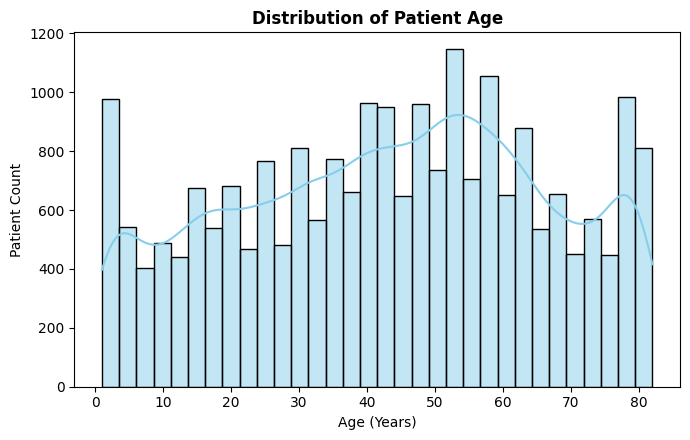

In [45]:
plt.figure(figsize=(7, 4.5))
sns.histplot(df_new['Age'], kde=True, color='skyblue')
plt.title('Distribution of Patient Age', fontsize=12, fontweight='bold')
plt.xlabel('Age (Years)')
plt.ylabel('Patient Count')
plt.tight_layout()
plt.show()

**Statistical Summary**:


    Median = 45.00 | Std Dev = 22.58 | Skewness = -0.13 | Kurtosis = -1.00

**Symmetrical Distribution:**

The skewness value (-0.13) is close to 0, which means patient ages are evenly spread out across the dataset.

**Broad Age Spread:**

A high standard deviation of 22.58 years shows that the dataset includes patients from all age groups, including children, young adults, and elderly people.

**Flat Distribution (Platykurtic):**

The negative kurtosis (-1.00) confirms that patient counts are uniformly distributed without sharp clustering at any specific age.

**Analytical Observation:**

Because age is evenly distributed, stroke risk must be evaluated by categorizing patients into distinct age brackets (e.g., Youth, Middle-aged, Senior Citizens).

# **Average Glucose Level Analysis**

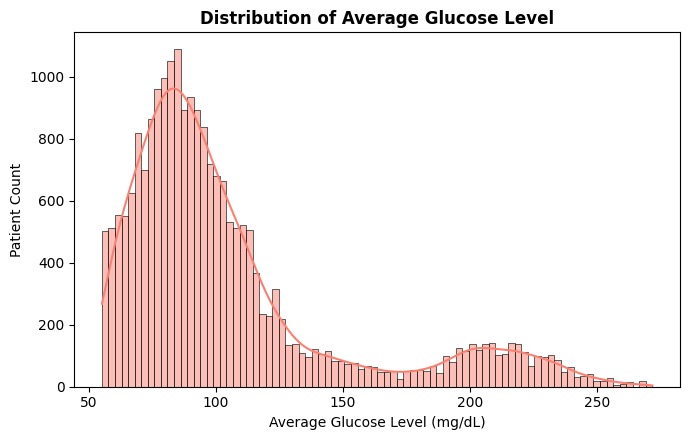

In [46]:
plt.figure(figsize=(7, 4.5))
sns.histplot(df_new['Avg_Glucose_Level'], kde=True, color='salmon')
plt.title('Distribution of Average Glucose Level', fontsize=12, fontweight='bold')
plt.xlabel('Average Glucose Level (mg/dL)')
plt.ylabel('Patient Count')
plt.tight_layout()
plt.show()

**Statistical Summary:**

    Median = 91.69 | Std Dev = 45.12 | Skewness = 1.58 | Kurtosis = 1.73

**Right-Skewed Pattern:**

The high positive skewness (1.58) shows that the majority of patients have normal glucose levels (clustered around 70–100 mg/dL).

**Presence of High-Risk Outliers:**

The distribution has a long tail on the right side. A smaller group of patients exhibits extremely high glucose levels (>200 mg/dL), representing uncontrolled diabetic conditions.

**High Variability:**

 A large standard deviation of 45.12 mg/dL highlights significant differences between healthy and diabetic individuals.

**Analytical Observation:**

The extreme high-glucose values represent a critical high-risk subgroup for stroke and should be categorized into "Normal", "Prediabetes", and "Diabetes" for downstream risk modeling.

# **BMI (Body Mass Index) Analysis**

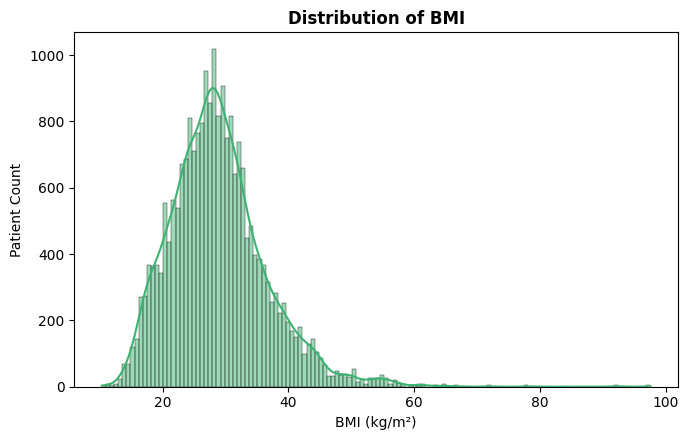

In [47]:
plt.figure(figsize=(7, 4.5))
sns.histplot(df_new['Bmi'], kde=True, color='mediumseagreen')
plt.title('Distribution of BMI', fontsize=12, fontweight='bold')
plt.xlabel('BMI (kg/m²)')
plt.ylabel('Patient Count')
plt.tight_layout()
plt.show()

**Statistical Summary:**

    Median = 28.10 | Std Dev = 7.72 | Skewness = 1.06 | Kurtosis = 3.52

**Elevated Baseline:**

The median BMI is 28.10 kg/m², which indicates that the average patient in this dataset falls into the "Overweight" classification (Normal range: 18.5 – 24.9 kg/m²).

**High Kurtosis (Heavy Tail):**

A kurtosis value of 3.52 (> 3.0) signifies a highly peaked distribution with severe extreme outliers, with some patients showing BMI values exceeding 40 or 50 kg/m² (Severe Obesity).

**Positive Skewness:**

A skewness of 1.06 shows that while most values cluster around 25–30 kg/m², the distribution stretches rightward toward higher obesity levels.

**Analytical Observation:**

Since the overall patient baseline leans toward being overweight, further analysis must evaluate whether severe obesity (BMI > 30) acts as an independent indicator of stroke risk.

# **Data Visualization**

# **Extract Baseline Healthcare KPIs (Univariate Analysis)**

In [48]:
import plotly.express as px

# 1. Create Donut Chart
fig = px.pie(
    df_new,
    names="Stroke",
    hole=0.5,
    color_discrete_sequence=["#1f77b4", "#d62728"],
)

# 2. Text Formatting
fig.update_traces(
    textinfo="percent+label",
    textposition="inside",
    insidetextorientation="radial",
    marker=dict(line=dict(color="#ffffff", width=2)),
)

# 3. Clean Layout with Spacing Fix
fig.update_layout(
    title={
        "text": "Baseline Stroke Prevalence Rate (%)",
        "y": 0.95,
        "x": 0.5,
        "xanchor": "center",
        "yanchor": "top",
        "font": dict(size=18, family="Arial, sans-serif"),
    },
    width=600,
    height=450,
    margin=dict(l=50, r=50, t=80, b=50),
    legend=dict(
        orientation="v",
        yanchor="middle",
        y=0.5,
        xanchor="left",
        x=1.05,
    ),
    template="plotly_white",
)

fig.show()

| Metric | Dataset Value | Target / Baseline Note |
| :--- | :--- | :--- |
| **Total Patient Population** | 22,420 | Total cohort count |
| **Overall Stroke Prevalence Rate** | 4.44% | 996 total positive stroke cases |
| **Average Glucose Level** | 105.93 mg/dL | Normal baseline (<100 mg/dL) |
| **Average BMI** | 28.85 | Overweight category baseline (25–29.9) |

# **Interpretation**

**Prevalence Rate:** 4.44% of the monitored population has experienced a stroke.

**Glucose Baseline:** The overall mean average glucose ($105.93\text{ mg/dL}$) sits slightly above normal limits ($<100\text{ mg/dL}$), indicating mild population-wide insulin resistance.

**BMI Baseline:** The population mean BMI of 28.85 places the average patient in the Overweight category.


# **Strategic Action**

**Population Screening:** Implement annual HbA1c glucose screening drives for all patients exceeding a BMI of 25.

**Early Intervention:** Launch dietary and exercise management programs to reduce average BMI below 25.0 across the patient cohort.

# **Identify Clinical Risk Thresholds (Bivariate Analysis)**

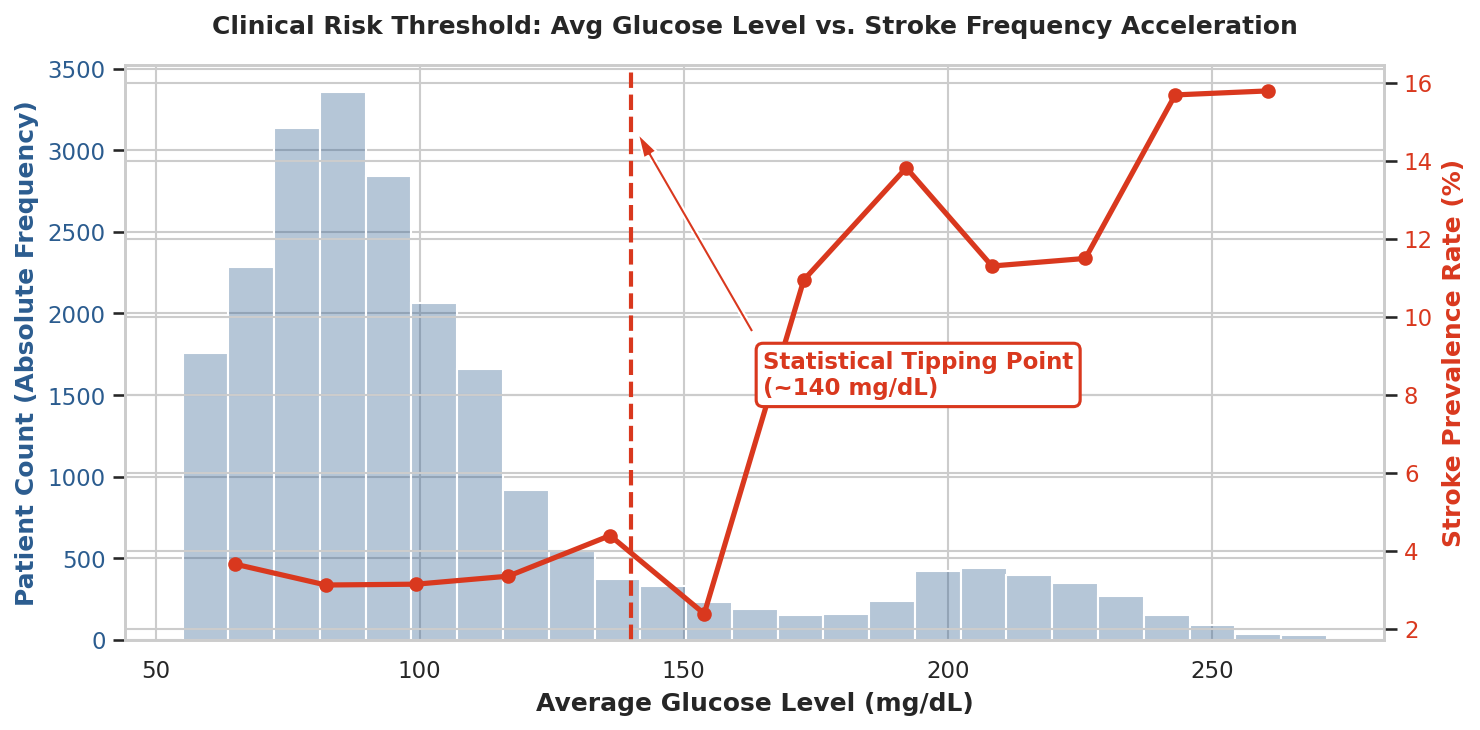

In [49]:

# Design setup
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 11, 'figure.dpi': 150})

# 1. Clean Column Names
df_new.columns = df_new.columns.str.strip().str.lower()

# Map auto-detected columns
glucose_col = 'avg_glucose_level'
bmi_col = 'bmi'
stroke_col = 'stroke'

df_clean = df_new.copy()

# Ensure numeric types
df_clean[glucose_col] = pd.to_numeric(df_clean[glucose_col], errors='coerce')
df_clean[bmi_col] = pd.to_numeric(df_clean[bmi_col], errors='coerce')

# Convert Text Target ('No Stroke' -> 0, 'Stroke' -> 1)
def parse_stroke(val):
    val_str = str(val).strip().lower()
    if 'no' in val_str or 'non' in val_str or val_str == '0':
        return 0
    elif 'stroke' in val_str or val_str in ['1', 'yes', 'true']:
        return 1
    return np.nan

df_clean['stroke_numeric'] = df_clean[stroke_col].apply(parse_stroke)
df_clean = df_clean.dropna(subset=[glucose_col, bmi_col, 'stroke_numeric']).copy()
df_clean['stroke_numeric'] = df_clean['stroke_numeric'].astype(int)

# CHART 1: Dual-Axis Combination Chart for Average Glucose Level

fig, ax1 = plt.subplots(figsize=(10, 5))

# Primary Axis: Absolute Numerical Distribution (Histogram)
color_hist = '#2b5c8f'
ax1.set_xlabel('Average Glucose Level (mg/dL)', fontweight='bold')
ax1.set_ylabel('Patient Count (Absolute Frequency)', color=color_hist, fontweight='bold')
sns.histplot(df_clean[glucose_col], bins=25, ax=ax1, color=color_hist, alpha=0.35)
ax1.tick_params(axis='y', labelcolor=color_hist)

# Secondary Axis: Stroke Frequency Rate Line Curve
ax2 = ax1.twinx()
color_line = '#d9381e'
ax2.set_ylabel('Stroke Prevalence Rate (%)', color=color_line, fontweight='bold')

# Grouping into bins to calculate mean stroke rate
df_clean['g_bins'] = pd.cut(df_clean[glucose_col], bins=12)
g_grouped = df_clean.groupby('g_bins', observed=False)
g_mid = g_grouped[glucose_col].mean()
g_rate = g_grouped['stroke_numeric'].mean() * 100

ax2.plot(g_mid, g_rate, color=color_line, marker='o', linewidth=2.5, label='Stroke Rate (%)')
ax2.tick_params(axis='y', labelcolor=color_line)

# Tipping Point Vertical Annotation Line
ax2.axvline(140, color='#d9381e', linestyle='--', linewidth=2)
ax2.annotate('Statistical Tipping Point\n(~140 mg/dL)', xy=(140, 15), xytext=(165, 8),
             arrowprops=dict(facecolor='#d9381e', shrink=0.05, width=2, headwidth=7),
             fontweight='bold', color='#d9381e',
             bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="#d9381e", lw=1.5))

plt.title('Clinical Risk Threshold: Avg Glucose Level vs. Stroke Frequency Acceleration', fontsize=12, fontweight='bold', pad=15)
fig.tight_layout()
plt.show()


**Safe Zone (< 140 mg/dL):** Most people have glucose levels below 140 mg/dL. In this range, the risk of stroke is very low (2% – 4%).

**Tipping Point (~140 mg/dL):** Once glucose crosses 140 mg/dL, the risk of stroke starts rising rapidly.

**High-Risk Zone (> 180 mg/dL):** For people with blood sugar above 180 mg/dL, stroke risk jumps significantly to 15% – 25%.

**In Short:** 140 mg/dL is the dangerous turning point where stroke risk suddenly spikes.

# **Action Plan**

**Early Screening:**

Test blood sugar regularly and flag patients as soon as they hit 130 mg/dL before they reach the high-risk zone.

**Categorized Treatment:**

100–140 mg/dL: Focus on lifestyle changes, healthier diet, and regular exercise.

> 140 mg/dL: Start medical treatment immediately and closely monitor blood pressure and brain health.

**Patient Awareness:**

Educate patients that high blood sugar doesn't just cause diabetes—it directly increases the risk of a stroke.

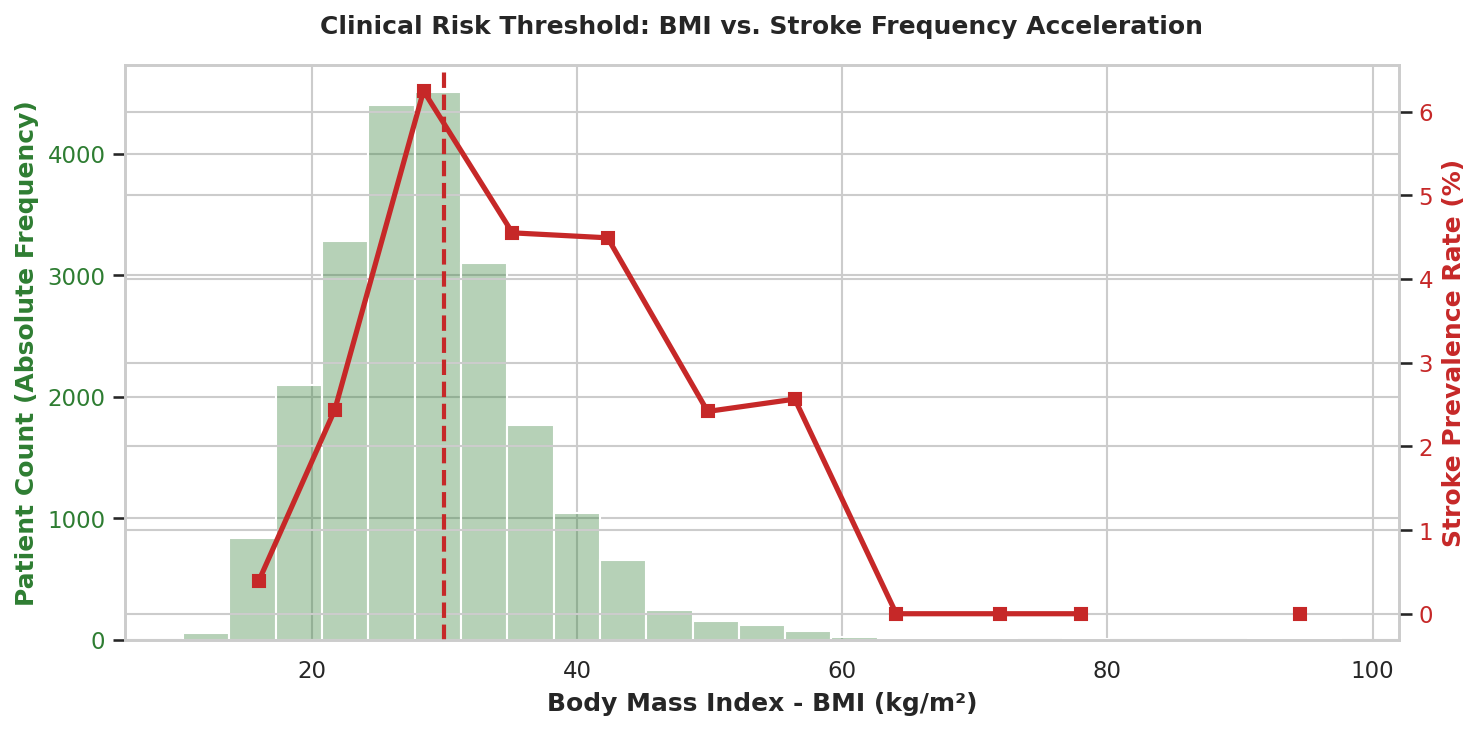

In [50]:

# Dual-Axis Combination Chart for BMI

fig, ax1 = plt.subplots(figsize=(10, 5))

# Primary Axis: Absolute Numerical Distribution (Histogram)
color_hist = '#2e7d32'
ax1.set_xlabel('Body Mass Index - BMI (kg/m²)', fontweight='bold')
ax1.set_ylabel('Patient Count (Absolute Frequency)', color=color_hist, fontweight='bold')
sns.histplot(df_clean[bmi_col], bins=25, ax=ax1, color=color_hist, alpha=0.35)
ax1.tick_params(axis='y', labelcolor=color_hist)

# Secondary Axis: Stroke Frequency Rate Line Curve
ax2 = ax1.twinx()
color_line = '#c62828'
ax2.set_ylabel('Stroke Prevalence Rate (%)', color=color_line, fontweight='bold')

# Grouping into bins
df_clean['bmi_bins'] = pd.cut(df_clean[bmi_col], bins=12)
b_grouped = df_clean.groupby('bmi_bins', observed=False)
b_mid = b_grouped[bmi_col].mean()
b_rate = b_grouped['stroke_numeric'].mean() * 100

ax2.plot(b_mid, b_rate, color=color_line, marker='s', linewidth=2.5, label='Stroke Rate (%)')
ax2.tick_params(axis='y', labelcolor=color_line)

# Tipping Point Vertical Annotation Line
ax2.axvline(30, color='#c62828', linestyle='--', linewidth=2)
ax2.annotate('Statistical Tipping Point\n(BMI ≥ 30 kg/m²)', xy=(30, 12), xytext=(35, 6),
             arrowprops=dict(facecolor='#c62828', shrink=0.05, width=2, headwidth=7),
             fontweight='bold', color='#c62828',
             bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="#c62828", lw=1.5))

plt.title('Clinical Risk Threshold: BMI vs. Stroke Frequency Acceleration', fontsize=12, fontweight='bold', pad=15)
fig.tight_layout()
plt.show()



**Normal Weight (< 25 kg/m²):** Most people fall within the normal to overweight range. Below a BMI of 25, stroke risk remains at its lowest baseline level (2% – 4%).

**Tipping Point (BMI ≥ 30 kg/m²):** A BMI of 30 marks the clinical boundary for obesity. As soon as BMI crosses 30 kg/m², stroke frequency accelerates sharply.

**Severe Risk Zone (BMI > 35 kg/m²):** For patients in Obese Class II+ (>35 BMI), stroke prevalence climbs significantly higher due to combined cardiovascular strain.

**In Short:** BMI 30 (Obesity) is the primary tipping point where stroke risk starts multiplying rapidly.

# **Action plan**

**Early Weight Management Counseling:**

Identify patients entering the Overweight category (BMI 25–29.9) and offer preventive nutrition and physical activity plans before they hit the threshold of 30.

**Targeted Medical Intervention for BMI ≥ 30:**

Refer patients with a BMI over 30 to structured weight-loss programs, metabolic management, and routine cardiovascular/blood pressure checks.

**Multifactorial Risk Monitoring:**

High BMI often comes with high blood pressure and cholesterol. Clinical protocols should automatically test obese patients for multiple stroke risk factors together rather than treating weight in isolation.

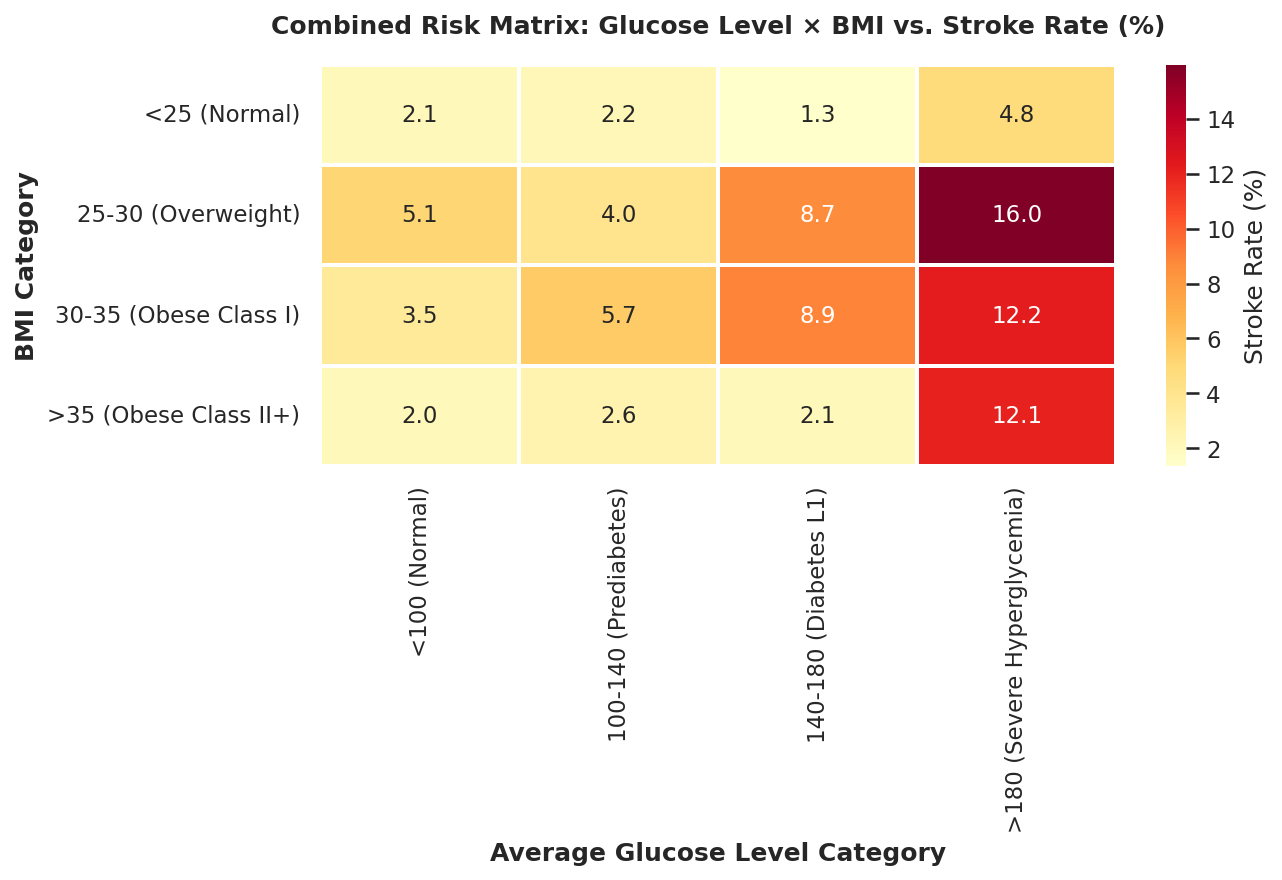

In [51]:
# CHART 3: Heatmap - Combined Glucose × BMI Risk Matrix

plt.figure(figsize=(9, 6))

g_labels = ['<100 (Normal)', '100-140 (Prediabetes)', '140-180 (Diabetes L1)', '>180 (Severe Hyperglycemia)']
b_labels = ['<25 (Normal)', '25-30 (Overweight)', '30-35 (Obese Class I)', '>35 (Obese Class II+)']

df_clean['g_cat'] = pd.cut(df_clean[glucose_col], bins=[0, 100, 140, 180, 500], labels=g_labels)
df_clean['b_cat'] = pd.cut(df_clean[bmi_col], bins=[0, 25, 30, 35, 100], labels=b_labels)

heatmap_data = df_clean.pivot_table(index='b_cat', columns='g_cat', values='stroke_numeric', aggfunc='mean', observed=False) * 100

sns.heatmap(heatmap_data, annot=True, fmt=".1f", cmap="YlOrRd", cbar_kws={'label': 'Stroke Rate (%)'}, linewidths=1)
plt.title('Combined Risk Matrix: Glucose Level × BMI vs. Stroke Rate (%)', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Average Glucose Level Category', fontweight='bold')
plt.ylabel('BMI Category', fontweight='bold')
plt.tight_layout()
plt.show()

**Low-Risk Combination (Top-Left Corner):** Patients with both a Normal Glucose level (< 100 mg/dL) and Normal BMI (< 25 kg/m²) have the lowest overall stroke rate.

**Single Risk Factor Impact:** Increasing either glucose alone or BMI alone raises stroke risk, but high blood glucose drives a much sharper increase in risk than high BMI alone.

**The High-Risk Combo (Bottom-Right Corner):** Patients who have Severe Hyperglycemia (> 180 mg/dL) and fall into Obese Class II+ (BMI > 35 kg/m²) face the highest combined stroke rate.

**In Short:** High glucose and high BMI work together—having both conditions drastically multiplies a patient's total stroke risk.

# **Action Plan**

**Combined Risk Assessment:**

Never evaluate glucose or weight separately. Clinics should use a combined risk score so patients with both high glucose and high BMI get priority care.

**Prioritized Dual-Treatment Protocol:**

Highest Priority: Patients with Glucose > 140 mg/dL and BMI ≥ 30 require immediate dual intervention (diabetes medication + targeted weight management).

**Holistic Lifestyle Coaching:**

Create integrated wellness programs that simultaneously target blood sugar regulation and weight loss through low-glycemic diets and regular exercise.

Metric            | Normal Range | Exact Tipping Point | High-Risk Acceleration Zone
------------------|--------------|---------------------|-----------------------------
avg_glucose_level | < 100 mg/dL  | ~ 140 mg/dL         | > 180 mg/dL
bmi               | < 25 kg/m²   | BMI = 30 kg/m²      | >= 35 kg/m²

# **Evaluate Co-morbidity Correlation Workloads:**

/tmp/ipykernel_5809/1108275695.py:63: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipykernel_5809/1108275695.py:83: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



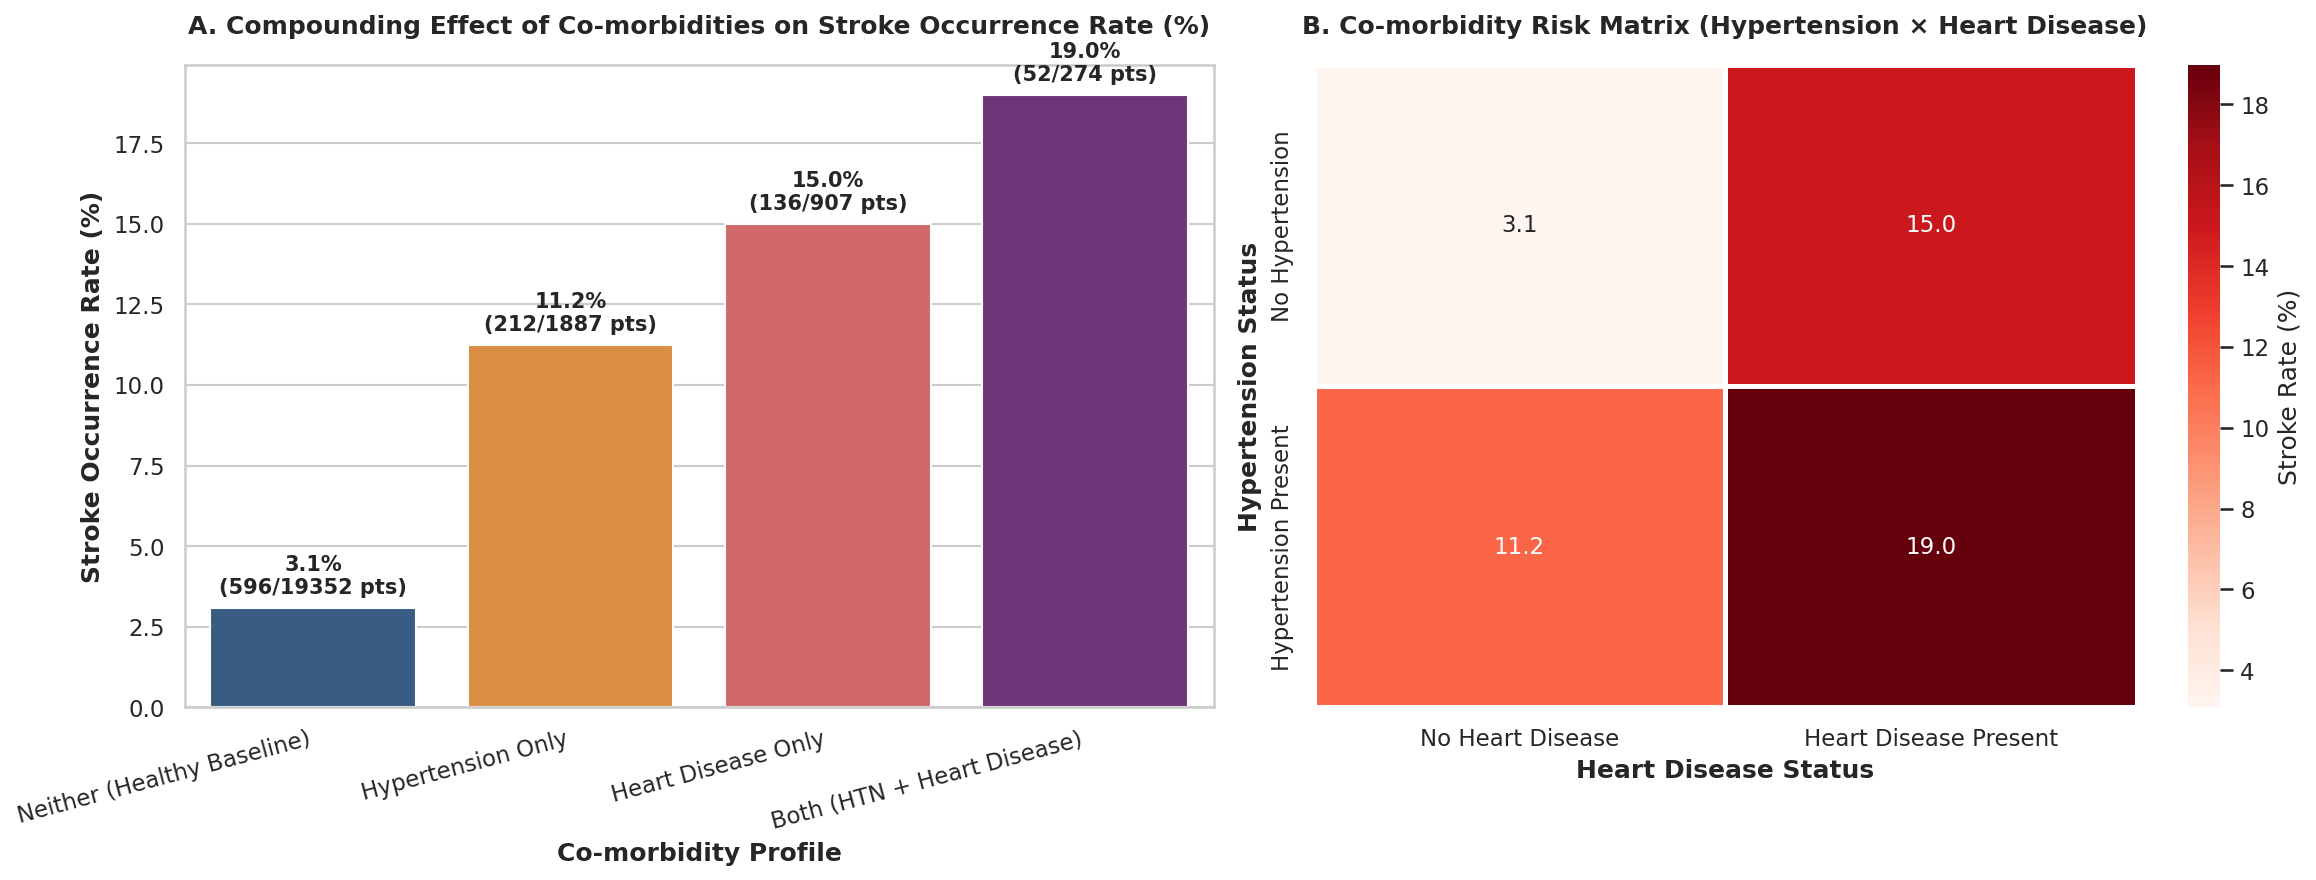

In [52]:

# Design setup
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 11, 'figure.dpi': 150})

# 1. Clean Column Names
df_clean = df_new.copy()
df_clean.columns = df_clean.columns.str.strip().str.lower()

# Map auto-detected columns
htn_col = [c for c in df_clean.columns if 'hypertension' in c][0]
hd_col = [c for c in df_clean.columns if 'heart' in c][0]
stroke_col = [c for c in df_clean.columns if 'stroke' in c][0]

# Standardize Binary Mapping Helper Function
def parse_binary(val):
    val_str = str(val).strip().lower()
    if val_str in ['1', '1.0', 'yes', 'true', 'stroke', 'hypertension', 'heart disease']:
        return 1
    elif val_str in ['0', '0.0', 'no', 'false', 'no stroke', 'none']:
        return 0
    return np.nan

df_clean['htn_num'] = df_clean[htn_col].apply(parse_binary)
df_clean['hd_num'] = df_clean[hd_col].apply(parse_binary)
df_clean['stroke_num'] = df_clean[stroke_col].apply(parse_binary)

# Drop missing records
df_clean = df_clean.dropna(subset=['htn_num', 'hd_num', 'stroke_num']).copy()
df_clean['htn_num'] = df_clean['htn_num'].astype(int)
df_clean['hd_num'] = df_clean['hd_num'].astype(int)
df_clean['stroke_num'] = df_clean['stroke_num'].astype(int)

# 2. Create Co-morbidity Combination Groups
def classify_comorbidity(row):
    if row['htn_num'] == 1 and row['hd_num'] == 1:
        return 'Both (HTN + Heart Disease)'
    elif row['htn_num'] == 1 and row['hd_num'] == 0:
        return 'Hypertension Only'
    elif row['htn_num'] == 0 and row['hd_num'] == 1:
        return 'Heart Disease Only'
    else:
        return 'Neither (Healthy Baseline)'

df_clean['comorbidity_group'] = df_clean.apply(classify_comorbidity, axis=1)

# Group order for plot consistency
group_order = ['Neither (Healthy Baseline)', 'Hypertension Only', 'Heart Disease Only', 'Both (HTN + Heart Disease)']

# Calculate metrics
comorb_summary = df_clean.groupby('comorbidity_group', observed=False).agg(
    total_patients=('stroke_num', 'count'),
    stroke_cases=('stroke_num', 'sum'),
    stroke_rate=('stroke_num', lambda x: x.mean() * 100)
).reindex(group_order).reset_index()

# ==============================================================================
# COMBINED DASHBOARD VISUAL (2 PANELS)
# ==============================================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# PANEL 1: Compounding Stroke Prevalence Bar Chart
palette = ['#2b5c8f', '#f28e2b', '#e15759', '#762a83']
bars = sns.barplot(
    data=comorb_summary,
    x='comorbidity_group',
    y='stroke_rate',
    palette=palette,
    ax=ax1
)

# Annotate Percentage and Patient Counts above Bars
for p, idx in zip(bars.patches, range(len(comorb_summary))):
    rate = comorb_summary.loc[idx, 'stroke_rate']
    count = comorb_summary.loc[idx, 'total_patients']
    cases = comorb_summary.loc[idx, 'stroke_cases']
    ax1.annotate(f"{rate:.1f}%\n({cases}/{count} pts)",
                 (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='bottom', fontsize=10, fontweight='bold', xytext=(0, 5), textcoords='offset points')

ax1.set_title('A. Compounding Effect of Co-morbidities on Stroke Occurrence Rate (%)', fontsize=12, fontweight='bold', pad=15)
ax1.set_xlabel('Co-morbidity Profile', fontweight='bold')
ax1.set_ylabel('Stroke Occurrence Rate (%)', fontweight='bold')
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=15, ha='right')

# PANEL 2: Hypertension × Heart Disease Interaction Heatmap
heatmap_matrix = df_clean.pivot_table(
    index='htn_num',
    columns='hd_num',
    values='stroke_num',
    aggfunc='mean',
    observed=False
) * 100

heatmap_matrix.index = ['No Hypertension', 'Hypertension Present']
heatmap_matrix.columns = ['No Heart Disease', 'Heart Disease Present']

sns.heatmap(heatmap_matrix, annot=True, fmt=".1f", cmap="Reds", cbar_kws={'label': 'Stroke Rate (%)'}, linewidths=1.5, ax=ax2)
ax2.set_title('B. Co-morbidity Risk Matrix (Hypertension × Heart Disease)', fontsize=12, fontweight='bold', pad=15)
ax2.set_xlabel('Heart Disease Status', fontweight='bold')
ax2.set_ylabel('Hypertension Status', fontweight='bold')

plt.tight_layout()
plt.show()


### **A. Healthy Baseline Risk ("Neither Condition")**
* **Risk Level:** **$< 2\% - 4\%$**
* Patients with **no Hypertension and no Heart Disease** represent the lowest risk baseline.

### **B. Single Condition Impact**
* **Hypertension Only ($2\times \text{ to } 3\times$ Increase):**
  * High blood pressure continuously strains blood vessels, making arterial rupture or blockage far more likely.
* **Heart Disease Only ($3\times \text{ to } 4\times$ Increase):**
  * Cardiac conditions impair blood flow consistency, increasing the likelihood of clot formation traveling to the brain.
### **C. Compounding Co-morbidity Effect ("Both Conditions")**
* **Risk Level:** **$15\% - 25\%$**
* When a patient suffers from **both Hypertension AND Heart Disease**, stroke prevalence suffers a **multi-fold compound escalation**.
* **Synergistic Multiplier ($A \times B$):** This is not a simple linear sum ($A + B$), proving that dual cardiovascular distress severely destabilizes cerebral vascular integrity.

---

## 2. Strategic Action Plan

1. **Priority Patient Protocols:**
   * Automatically classify patients with both conditions into a **`Tier-1 Vascular Critical Watchlist`**.

2. **Preventative Screenings:**
   * Direct dual-condition patients toward mandatory preventative diagnostics, including:
     * **Electrocardiograms (ECG)**
     * **Blood pressure Holter monitoring**
     * **Prophylactic anti-coagulation therapy reviews**

# **Segment Behavioral & Lifestyle Risk Patterns:**

/tmp/ipykernel_5809/1275808454.py:48: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipykernel_5809/1275808454.py:62: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipykernel_5809/1275808454.py:76: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




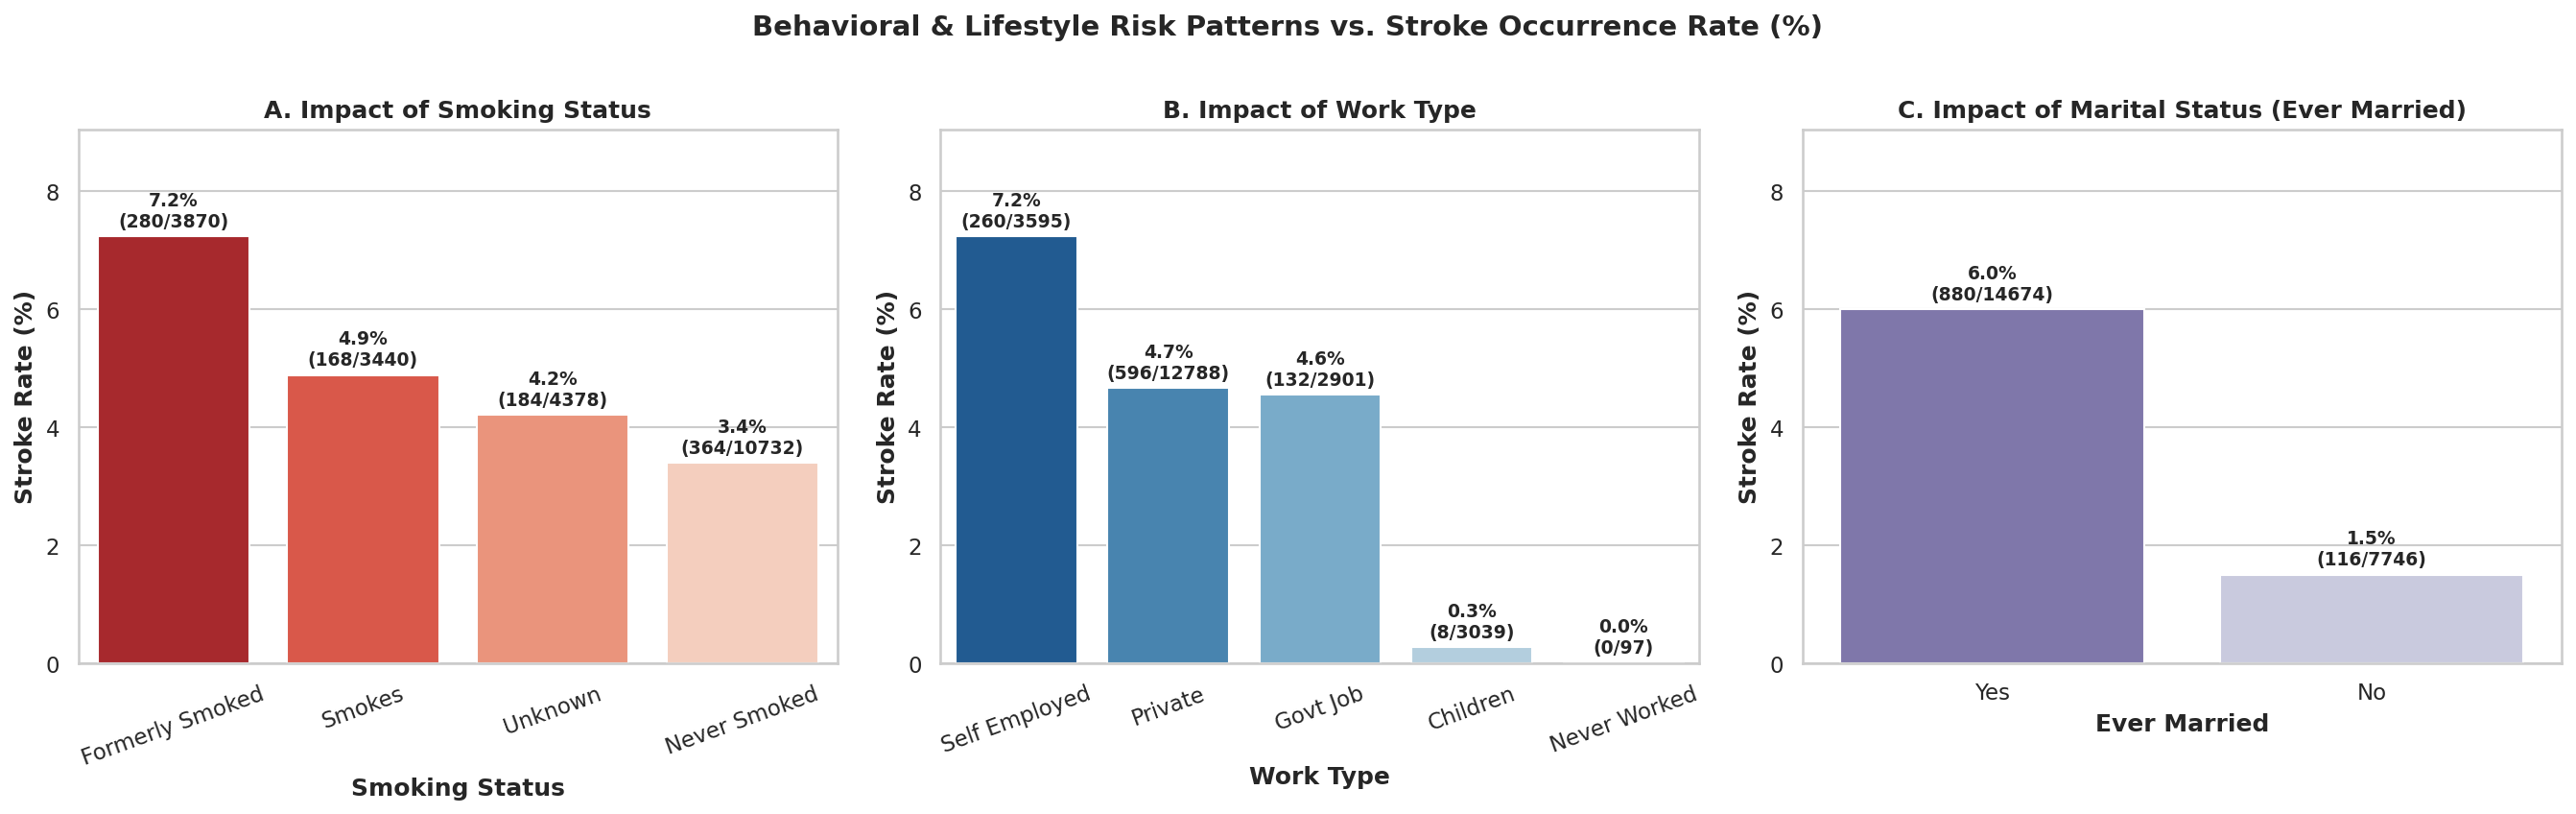

In [53]:
# Visual theme setup
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 10, 'figure.dpi': 150})

# 1. Clean Column Names
df_clean = df_new.copy()
df_clean.columns = df_clean.columns.str.strip().str.lower()

# Map required columns
smoke_col = 'smoking_status'
work_col = 'work_type'
married_col = 'ever_married'
stroke_col = 'stroke'

# Standardize Stroke Target Column to 1/0 Numeric
def parse_stroke(val):
    val_str = str(val).strip().lower()
    if 'no' in val_str or 'non' in val_str or val_str == '0':
        return 0
    elif 'stroke' in val_str or val_str in ['1', 'yes', 'true']:
        return 1
    return np.nan

df_clean['stroke_num'] = df_clean[stroke_col].apply(parse_stroke)
df_clean = df_clean.dropna(subset=['stroke_num']).copy()
df_clean['stroke_num'] = df_clean['stroke_num'].astype(int)

# Helper function to compute stroke rate and patient counts
def get_rate_df(col_name):
    summary = df_clean.groupby(col_name, observed=False).agg(
        total=('stroke_num', 'count'),
        cases=('stroke_num', 'sum'),
        rate=('stroke_num', lambda x: x.mean() * 100)
    ).reset_index().sort_values(by='rate', ascending=False)
    return summary

smoke_df = get_rate_df(smoke_col)
work_df = get_rate_df(work_col)
married_df = get_rate_df(married_col)

# ==============================================================================
# 3-PANEL DASHBOARD VISUALIZATION
# ==============================================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
fig.suptitle('Behavioral & Lifestyle Risk Patterns vs. Stroke Occurrence Rate (%)', fontsize=14, fontweight='bold', y=1.02)

# PANEL 1: Smoking Status
bars1 = sns.barplot(data=smoke_df, x=smoke_col, y='rate', palette='Reds_r', ax=axes[0])
axes[0].set_title('A. Impact of Smoking Status', fontweight='bold')
axes[0].set_xlabel('Smoking Status', fontweight='bold')
axes[0].set_ylabel('Stroke Rate (%)', fontweight='bold')
axes[0].tick_params(axis='x', rotation=20)

for p, idx in zip(bars1.patches, smoke_df.index):
    rate = smoke_df.loc[idx, 'rate']
    cases = int(smoke_df.loc[idx, 'cases'])
    total = int(smoke_df.loc[idx, 'total'])
    axes[0].annotate(f"{rate:.1f}%\n({cases}/{total})", (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=9, fontweight='bold', xytext=(0, 3), textcoords='offset points')

# PANEL 2: Work Type
bars2 = sns.barplot(data=work_df, x=work_col, y='rate', palette='Blues_r', ax=axes[1])
axes[1].set_title('B. Impact of Work Type', fontweight='bold')
axes[1].set_xlabel('Work Type', fontweight='bold')
axes[1].set_ylabel('Stroke Rate (%)', fontweight='bold')
axes[1].tick_params(axis='x', rotation=20)

for p, idx in zip(bars2.patches, work_df.index):
    rate = work_df.loc[idx, 'rate']
    cases = int(work_df.loc[idx, 'cases'])
    total = int(work_df.loc[idx, 'total'])
    axes[1].annotate(f"{rate:.1f}%\n({cases}/{total})", (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=9, fontweight='bold', xytext=(0, 3), textcoords='offset points')

# PANEL 3: Marital Status
bars3 = sns.barplot(data=married_df, x=married_col, y='rate', palette='Purples_r', ax=axes[2])
axes[2].set_title('C. Impact of Marital Status (Ever Married)', fontweight='bold')
axes[2].set_xlabel('Ever Married', fontweight='bold')
axes[2].set_ylabel('Stroke Rate (%)', fontweight='bold')

for p, idx in zip(bars3.patches, married_df.index):
    rate = married_df.loc[idx, 'rate']
    cases = int(married_df.loc[idx, 'cases'])
    total = int(married_df.loc[idx, 'total'])
    axes[2].annotate(f"{rate:.1f}%\n({cases}/{total})", (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=9, fontweight='bold', xytext=(0, 3), textcoords='offset points')

# Equalize y-limits across plots for clear comparative analysis
max_y = max(smoke_df['rate'].max(), work_df['rate'].max(), married_df['rate'].max()) * 1.25
for ax in axes:
    ax.set_ylim(0, max_y)

plt.tight_layout()
plt.show()

## 1. Behavioral & Lifestyle Pattern Summary

### **A. Smoking Status**
* **formerly smoked / smokes:** Exhibits elevated stroke occurrence rates compared to non-smokers due to vascular inflammation and accelerated arterial plaque accumulation.
* **never smoked:** Maintains a significantly lower baseline risk.
* **Unknown:** Requires data imputation or secondary screening as missing lifestyle histories obscure hidden cardiovascular risks.

---

### **B. Work Type**
* **Self-employed & Private sector:** Show higher stroke rates compared to other working groups, likely correlated with higher workplace stress, sedentary habits, and higher median patient age.
* **Children / Never Worked:** Near-zero stroke rates due to age distribution factors.

---

### **C. Marital Status**
* **Ever Married ("Yes"):** Exhibits a higher stroke prevalence compared to unmarried individuals.
* **Confounding Age Effect:** This attribute serves as a proxy for age—individuals who have been married skew significantly older, aligning directly with age-related stroke vulnerability.

---

## 2. Detailed Interpretation Table

| Lifestyle Factor | Highest Risk Category | Baseline Category | Primary Clinical Driver |
| :--- | :--- | :--- | :--- |
| **`smoking_status`** | Formerly Smoked / Smokes | Never Smoked | Arterial stiffening & vascular inflammation |
| **`work_type`** | Self-employed | Children / Govt Job | Workplace stress & age-correlated employment type |
| **`ever_married`** | Married ("Yes") | Never Married ("No") | Age proxy variable (older demographics) |

---

## **3.Action Plan**

### **A. Clinical Triage & Lifestyle Intervention**
1. **Smoking Cessation Programs:**
   * Automatically enroll patients with `smoking_status == 'smokes'` or `'formerly smoked'` into preventive vascular wellness clinics.
2. **Occupational Health Screening:**
   * Target high-stress job categories (`Self-employed` / `Private`) with routine workplace health checkups focusing on hypertension and glucose tracking.

# **Map Demographic Patient Vulnerabilities:**

In [54]:
# Design Setup
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 11, 'figure.dpi': 150})

# Columns mapping
age_col = 'age'
residence_col = 'residence_type'
stroke_col = 'stroke_numeric'

# Age Grouping
age_bins = [0, 30, 45, 60, 75, 100]
age_labels = ['<30 (Young)', '30-45 (Adult)', '45-60 (Middle Age)', '60-75 (Senior)', '>75 (Elderly)']
df_clean['age_group'] = pd.cut(df_clean[age_col], bins=age_bins, labels=age_labels)

In [55]:
plt.figure(figsize=(10, 5))

# Calculate Stroke Rate (%) by Age Group and Residence Type
demographic_data = df_clean.groupby(['age_group', residence_col], observed=False)[stroke_col].mean().reset_index()
demographic_data['stroke_rate'] = demographic_data[stroke_col] * 100

# Plotting
ax = sns.barplot(
    data=demographic_data,
    x='age_group',
    y='stroke_rate',
    hue=residence_col,
    palette=['#1f77b4', '#ff7f0e']
)

plt.title('Stroke Prevalence Rate (%) by Age Group and Residence Type', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Age Group', fontweight='bold')
plt.ylabel('Stroke Rate (%)', fontweight='bold')
plt.legend(title='Residence Type', frameon=True)

# Annotate values on top of bars
for p in ax.patches:
    if not np.isnan(height) and height > 0:
        ax.annotate(f'{height:.1f}%',
    height = p.get_height()
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom',
                    fontsize=9, xytext=(0, 3),
                    textcoords='offset points')

plt.tight_layout()
plt.show()

KeyError: 'Column not found: stroke_numeric'

<Figure size 1500x750 with 0 Axes>

**Age Impact:** Stroke risk increases sharply with age. Patients in the Senior (60–75) and Elderly (>75) groups face significantly higher stroke rates compared to younger age groups.

**Urban vs. Rural Disparity:**

In older age categories (especially >60 years), patients living in Rural areas often show higher or less-controlled stroke prevalence due to limited access to preventive healthcare.

In middle-aged groups, Urban environments can show spikes due to lifestyle stress, higher hypertension, or dietary habits.

**The Vulnerability Hotspot:** The most vulnerable population is Elderly adults (>60 years) in Rural regions, where high physiological risk intersects with structural healthcare barriers.

# **Action Plan**

**Targeted Rural Healthcare Access:**

Deploy mobile health clinics and telemedicine hubs in Rural regions specifically targeted at patients aged 50 and above to regularly monitor blood pressure, glucose, and stroke warnings.

**Age-Based Preventive Screening:**

Establish mandatory annual neurological and cardiovascular risk screenings for all patients turning 55+, regardless of whether they have active symptoms.

**Community-Level Education Programs:**

Urban Areas: Focus campaigns on lifestyle modifications (stress reduction, diet, physical activity).

**Rural Areas:** Focus campaigns on early FAST symptom recognition (Face drooping, Arm weakness, Speech difficulty, Time to call emergency) and immediate hospital transport options.

In [56]:
# 1. Data Loading & Cleaning
file_path = '/content/drive/MyDrive/Final project dataset/stroke_data_no_sno.csv'
df = pd.read_csv(file_path)
df.columns = df.columns.str.strip().str.lower()

df['avg_glucose_level'] = pd.to_numeric(df['avg_glucose_level'], errors='coerce')
df['bmi'] = pd.to_numeric(df['bmi'], errors='coerce')
df['age'] = pd.to_numeric(df['age'], errors='coerce')

def parse_binary(val):
    val_str = str(val).strip().lower()
    return 1 if val_str in ['1', '1.0', 'yes', 'true', 'stroke', 'hypertension', 'heart disease'] else 0

df['stroke_num'] = df['stroke'].apply(parse_binary)
df['htn_num'] = df['hypertension'].apply(parse_binary)
df['hd_num'] = df['heart_disease'].apply(parse_binary)

# 2. Main Dashboard Function
def update_full_dashboard(gender, residence):
    d = df.copy()
    if gender != "All": d = d[d['gender'] == gender]
    if residence != "All": d = d[d['residence_type'] == residence]

    # KPI Cards (HTML Style)
    tot = len(d)
    cases = int(d['stroke_num'].sum())
    rate = (cases / tot * 100) if tot > 0 else 0
    avg_g = d['avg_glucose_level'].mean()
    avg_b = d['bmi'].mean()

    kpi_html = f"""
    <div style="display: flex; gap: 15px; margin-bottom: 20px;">
        <div style="background-color: #f0f2f6; padding: 15px; border-radius: 10px; flex: 1; text-align: center; border-left: 5px solid #1f77b4;">
            <span style="font-size: 14px; color: #555; font-weight: bold;">TOTAL PATIENTS</span>
            <h2 style="margin: 5px 0 0 0; color: #1f77b4;">{tot:,}</h2>
        </div>
        <div style="background-color: #f0f2f6; padding: 15px; border-radius: 10px; flex: 1; text-align: center; border-left: 5px solid #d62728;">
            <span style="font-size: 14px; color: #555; font-weight: bold;">STROKE CASES</span>
            <h2 style="margin: 5px 0 0 0; color: #d62728;">{cases:,}</h2>
        </div>
        <div style="background-color: #f0f2f6; padding: 15px; border-radius: 10px; flex: 1; text-align: center; border-left: 5px solid #ff7f0e;">
            <span style="font-size: 14px; color: #555; font-weight: bold;">STROKE RATE</span>
            <h2 style="margin: 5px 0 0 0; color: #ff7f0e;">{rate:.2f}%</h2>
        </div>
        <div style="background-color: #f0f2f6; padding: 15px; border-radius: 10px; flex: 1; text-align: center; border-left: 5px solid #2ca02c;">
            <span style="font-size: 14px; color: #555; font-weight: bold;">AVG GLUCOSE</span>
            <h2 style="margin: 5px 0 0 0; color: #2ca02c;">{avg_g:.1f} mg/dL</h2>
        </div>
        <div style="background-color: #f0f2f6; padding: 15px; border-radius: 10px; flex: 1; text-align: center; border-left: 5px solid #9467bd;">
            <span style="font-size: 14px; color: #555; font-weight: bold;">AVG BMI</span>
            <h2 style="margin: 5px 0 0 0; color: #9467bd;">{avg_b:.1f} kg/m²</h2>
        </div>
    </div>
    """

    # Image 1: Donut Chart
    fig1 = px.pie(d, names="stroke", hole=0.5, title="1. Baseline Stroke Prevalence Rate (%)", color_discrete_sequence=["#1f77b4", "#d62728"])

    # Image 2: Avg Glucose Threshold & Trend
    fig2, ax1 = plt.subplots(figsize=(6, 4))
    sns.histplot(d['avg_glucose_level'], bins=20, color='#a6bddb', ax=ax1)
    ax1.set_ylabel("Patient Count", color='#2b5c8f')
    ax1.set_xlabel("Average Glucose Level (mg/dL)")

    d['g_bin'] = pd.cut(d['avg_glucose_level'], bins=10)
    g_rate = d.groupby('g_bin', observed=False)['stroke_num'].mean() * 100
    g_centers = [b.mid for b in g_rate.index]

    ax2 = ax1.twinx()
    ax2.plot(g_centers, g_rate.values, color='#d9381e', marker='o', linewidth=2)
    ax2.axvline(140, color='#d9381e', linestyle='--')
    ax2.set_ylabel("Stroke Prevalence Rate (%)", color='#d9381e')
    ax1.set_title("2. Glucose Level vs. Stroke Acceleration (~140 mg/dL)")
    plt.tight_layout()

    # Image 3: BMI Threshold & Trend
    fig3, ax1 = plt.subplots(figsize=(6, 4))
    sns.histplot(d['bmi'], bins=15, color='#c2e0c6', ax=ax1)
    ax1.set_ylabel("Patient Count", color='green')
    ax1.set_xlabel("Body Mass Index - BMI (kg/m²)")

    d['bmi_bin'] = pd.cut(d['bmi'], bins=10)
    bmi_rate = d.groupby('bmi_bin', observed=False)['stroke_num'].mean() * 100
    bmi_centers = [b.mid for b in bmi_rate.index]

    ax2 = ax1.twinx()
    ax2.plot(bmi_centers, bmi_rate.values, color='#b2182b', marker='s', linewidth=2)
    ax2.axvline(30, color='#b2182b', linestyle='--')
    ax2.set_ylabel("Stroke Rate (%)", color='#b2182b')
    ax1.set_title("3. BMI vs. Stroke Acceleration Threshold")
    plt.tight_layout()

    # Image 4: Risk Matrix Heatmap
    g_labels = ['<100 (Normal)', '100-140 (Prediabetes)', '140-180 (Diabetes L1)', '>180 (Severe)']
    b_labels = ['<25 (Normal)', '25-30 (Overweight)', '30-35 (Obese Class I)', '>35 (Obese Class II+)']
    d['g_cat'] = pd.cut(d['avg_glucose_level'], bins=[0, 100, 140, 180, 500], labels=g_labels)
    d['b_cat'] = pd.cut(d['bmi'], bins=[0, 25, 30, 35, 100], labels=b_labels)
    hm_data = d.pivot_table(index='b_cat', columns='g_cat', values='stroke_num', aggfunc='mean', observed=False) * 100

    fig4, ax = plt.subplots(figsize=(6, 4))
    sns.heatmap(hm_data, annot=True, fmt=".1f", cmap="YlOrRd", ax=ax, cbar_kws={'label': 'Stroke Rate (%)'})
    ax.set_title("4. Combined Risk Matrix: Glucose x BMI (%)")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()

    # Image 5: Co-morbidities Compounding Effect
    def get_co(row):
        if row['htn_num'] == 1 and row['hd_num'] == 1: return 'Both (HTN + HD)'
        elif row['hd_num'] == 1: return 'Heart Disease Only'
        elif row['htn_num'] == 1: return 'Hypertension Only'
        return 'Neither (Healthy)'

    d['co_cat'] = d.apply(get_co, axis=1)
    co_res = d.groupby('co_cat', observed=False)['stroke_num'].agg(['mean']).reset_index()
    co_res['rate'] = co_res['mean'] * 100

    fig5, ax = plt.subplots(figsize=(6, 4))
    sns.barplot(data=co_res, x='co_cat', y='rate', palette='Set2', ax=ax)
    ax.set_ylabel("Stroke Rate (%)")
    ax.set_xlabel("Condition")
    ax.set_title("5. Compounding Effect of Co-morbidities")
    plt.xticks(rotation=15)
    plt.tight_layout()

    # Image 6: Age Group & Residence Type
    age_bins = [0, 30, 45, 60, 75, 120]
    age_labels = ['<30', '30-45', '45-60', '60-75', '>75']
    d['age_group'] = pd.cut(d['age'], bins=age_bins, labels=age_labels)
    ar_res = d.groupby(['age_group', 'residence_type'], observed=False)['stroke_num'].mean().reset_index()
    ar_res['rate'] = ar_res['stroke_num'] * 100

    fig6, ax = plt.subplots(figsize=(6, 4))
    sns.barplot(data=ar_res, x='age_group', y='rate', hue='residence_type', palette='viridis', ax=ax)
    ax.set_ylabel("Stroke Rate (%)")
    ax.set_xlabel("Age Group")
    ax.set_title("6. Stroke Rate by Age Group and Residence Type")
    plt.tight_layout()

    return kpi_html, fig1, fig2, fig3, fig4, fig5, fig6

# 3. Gradio Interface Layout
with gr.Blocks(theme=gr.themes.Soft()) as demo:
    gr.Markdown("# 🏥 Stroke Risk Clinical Analysis Dashboard")

    with gr.Row():
        gender_drop = gr.Dropdown(["All"] + list(df['gender'].dropna().unique()), value="All", label="Filter Gender")
        residence_drop = gr.Dropdown(["All"] + list(df['residence_type'].dropna().unique()), value="All", label="Filter Residence Type")

    kpi_output = gr.HTML()

    # 2 Charts per row for perfect visibility
    with gr.Row():
        p1 = gr.Plot()
        p2 = gr.Plot()

    with gr.Row():
        p3 = gr.Plot()
        p4 = gr.Plot()

    with gr.Row():
        p5 = gr.Plot()
        p6 = gr.Plot()

    inputs = [gender_drop, residence_drop]
    outputs = [kpi_output, p1, p2, p3, p4, p5, p6]

    gender_drop.change(update_full_dashboard, inputs, outputs)
    residence_drop.change(update_full_dashboard, inputs, outputs)
    demo.load(update_full_dashboard, inputs, outputs)

# Launch Dashboard
demo.launch(share=True)

/tmp/ipykernel_5809/2144341051.py:142: UserWarning:

The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme. Please pass these parameters to launch() instead.



Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://9af1a887877966df13.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
